# Harmonize data with neuroComBat

### Importing necesary moduls

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from uniharmony import verbosity
from uniharmony.combat import NeuroComBat
from uniharmony.datasets import make_multisite_classification


sns.set_theme(style="whitegrid")
verbosity("warning")

### Generate data using `unharmony` function

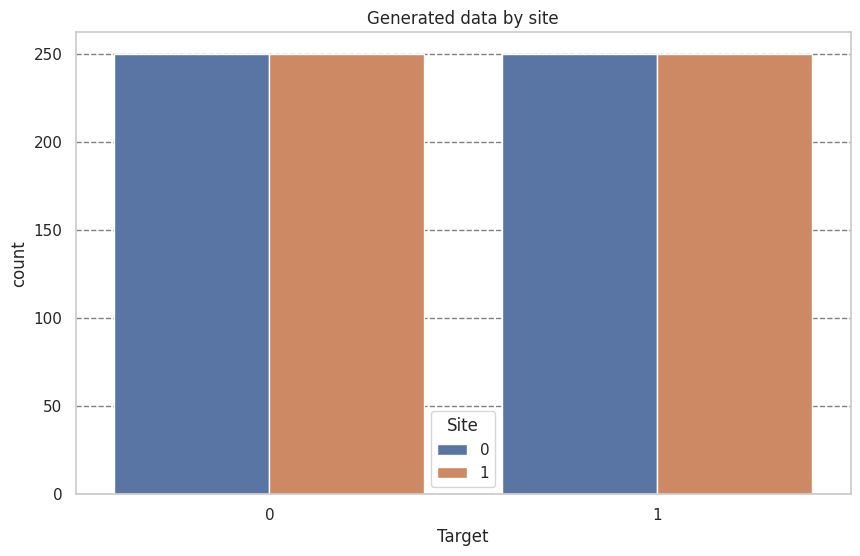

In [11]:
X, y, sites = make_multisite_classification(
    n_features=2,
    site_effect_strength=4,
)
df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Generated data by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

## Let's create a instance of the neuroCombat harmonizer

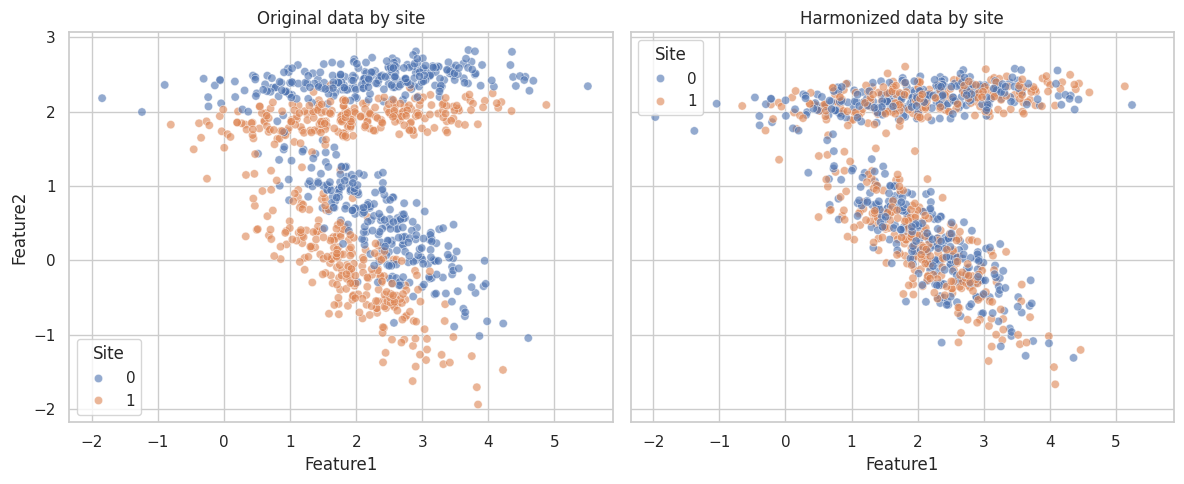

In [12]:
combat = NeuroComBat()
X_harmonized = combat.fit_transform(X, sites)
df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Phase"] = "Harmonized"

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
plt.tight_layout()

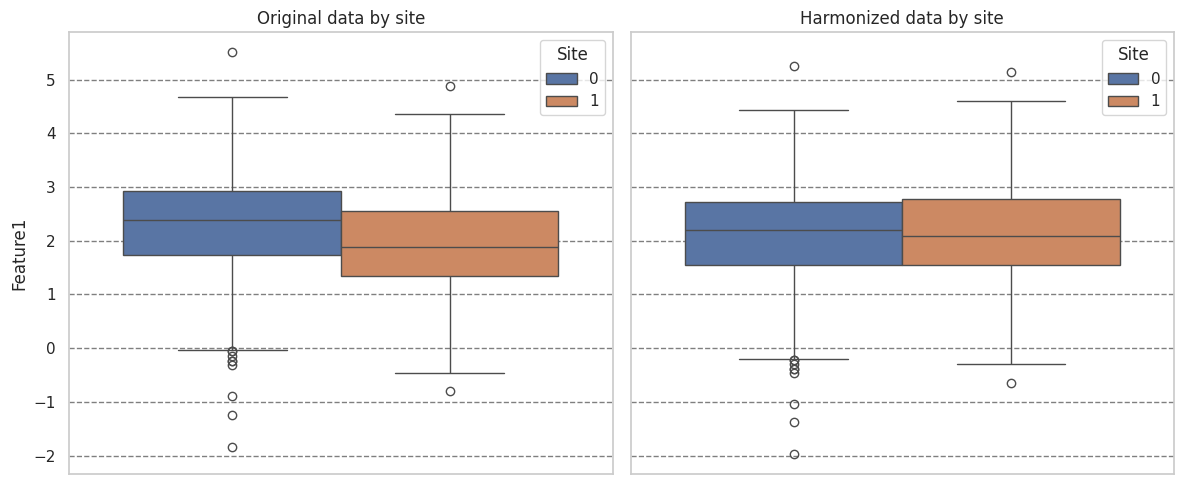

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.boxplot(data=df_orig, y="Feature1", hue="Site", ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(axis="y", color="black", alpha=0.5, linestyle="--")
sns.boxplot(data=df_harm, y="Feature1", hue="Site", ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()

In [14]:
print("Feature means by site before harmonization:")
print(df_orig["Feature1"].groupby(df_orig["Site"]).mean())
print("Feature means by site after harmonization:")
print(df_harm["Feature1"].groupby(df_harm["Site"]).mean())

Feature means by site before harmonization:
Site
0    2.307783
1    1.932366
Name: Feature1, dtype: float64
Feature means by site after harmonization:
Site
0    2.105410
1    2.134838
Name: Feature1, dtype: float64


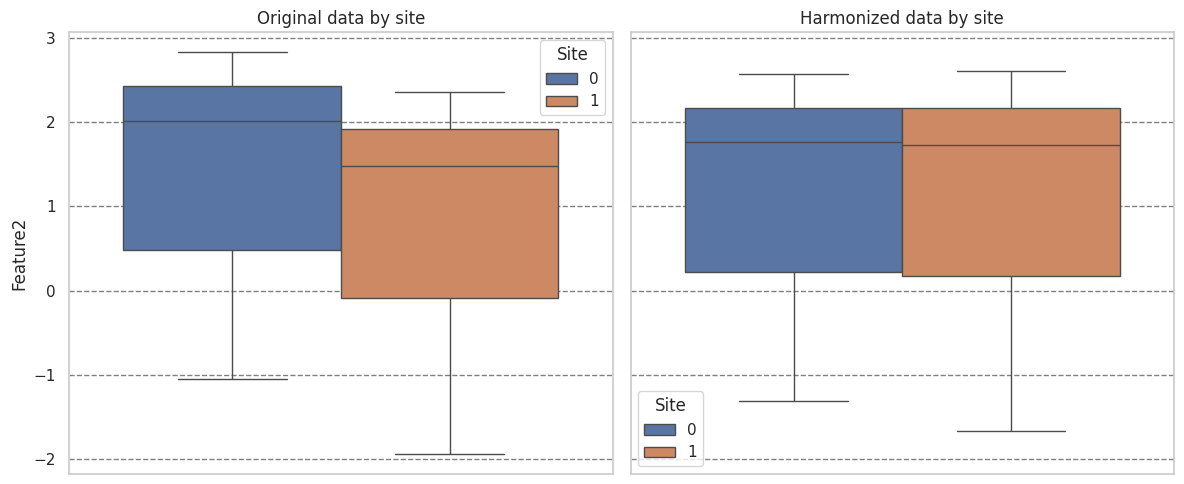

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.boxplot(data=df_orig, y="Feature2", hue="Site", ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(axis="y", color="black", alpha=0.5, linestyle="--")
sns.boxplot(data=df_harm, y="Feature2", hue="Site", ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()

In [16]:
print("Feature means by site before harmonization:")
print(df_orig["Feature2"].groupby(df_orig["Site"]).mean())
print("Feature means by site after harmonization:")
print(df_harm["Feature2"].groupby(df_harm["Site"]).mean())

Feature means by site before harmonization:
Site
0    1.452908
1    0.906348
Name: Feature2, dtype: float64
Feature means by site after harmonization:
Site
0    1.196567
1    1.162718
Name: Feature2, dtype: float64


# Take Home message
As expected, neuroComBat pushes the mean of the site distributions closer.